# 04 — XGBoost and Model Selection

Phase 4 compares the Phase 3 primary logistic baseline with a deliberately small set of regularized XGBoost candidates. The experiment is chronological and development-only:

- Month 0–4: fit preprocessing and model parameters.
- Month 5: diagnostic stability context only.
- Month 6: candidate ranking and locked promotion guardrails.
- Month 7: reserved test; features and labels are not exposed.

The selected object is a development candidate. Probability calibration and business-threshold selection remain deferred to Phase 5.

In [1]:
import json
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from fraudshield.config import load_config
from fraudshield.evaluate import build_error_analysis_frame
from fraudshield.model_selection import (
    run_phase4_experiment,
    xgboost_importance_frame,
)
from fraudshield.train import positive_class_probability

CONFIG_PATH = Path("../configs/base.yaml")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Locked experiment configuration

The candidate list and promotion policy are read before any model is fit. The search is an explicit shortlist, not an unconstrained hyperparameter sweep.

In [2]:
config = load_config(CONFIG_PATH)

candidate_frame = pd.DataFrame(config["xgboost"]["candidates"])
selection_policy = pd.Series(
    {
        "baseline_model": config["model_selection"]["baseline_model_name"],
        "primary_metric": config["model_selection"]["primary_metric"],
        "operational_review_rate": config["model_selection"]["operational_review_rate"],
        "minimum_absolute_ap_improvement": config["model_selection"]["minimum_absolute_ap_improvement"],
        "maximum_recall_at_capacity_drop": config["model_selection"]["maximum_recall_at_capacity_drop"],
        "selection_periods": config["model_selection"]["selection_periods"],
        "reserved_test_periods": config["split"]["test_periods"],
    },
    name="locked_value",
)

assert config["model_selection"]["selection_periods"] == config["split"]["validation_periods"]
assert set(config["model_selection"]["selection_periods"]).isdisjoint(config["split"]["test_periods"])
display(candidate_frame)
display(selection_policy.to_frame())

,name,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,xgboost_shallow_regularized,450,0.05,3,10.0,0.8,0.8,0.00,0.10,5.0
1,xgboost_moderate_depth,400,0.05,4,15.0,0.8,0.8,0.05,0.10,7.0
2,xgboost_strong_regularization,325,0.08,3,25.0,0.9,0.9,0.10,0.25,10.0


,locked_value
baseline_model,logistic_regression_balanced
primary_metric,pr_auc_average_precision
operational_review_rate,0.05
minimum_absolute_ap_improvement,0.002
maximum_recall_at_capacity_drop,0.01
selection_periods,[6]
reserved_test_periods,[7]


## 2. Run the complete Phase 4 experiment

The command below validates the raw schema, creates the temporal development partitions, retrains the Phase 3 primary baseline, trains every XGBoost candidate, evaluates month 5 and month 6, applies the locked model-selection rule, and saves local artifacts.

`scale_pos_weight` is calculated from the month 0–4 target only. Fixed boosting rounds are used; early stopping does not consume a later partition during fitting.

In [3]:
result = run_phase4_experiment(
    CONFIG_PATH,
    save_artifacts=True,
)
development_data = result.development_data

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "periods": config["split"]["train_periods"],
            "rows": len(development_data.train_target),
            "prevalence": development_data.train_target.mean(),
            "role": "fit preprocessing and models",
        },
        {
            "split": "calibration",
            "periods": config["split"]["calibration_periods"],
            "rows": len(development_data.calibration_target),
            "prevalence": development_data.calibration_target.mean(),
            "role": "diagnostic context only",
        },
        {
            "split": "validation",
            "periods": config["split"]["validation_periods"],
            "rows": len(development_data.validation_target),
            "prevalence": development_data.validation_target.mean(),
            "role": "ranking and model selection",
        },
        {
            "split": "reserved_test",
            "periods": config["split"]["test_periods"],
            "rows": development_data.reserved_test_rows,
            "prevalence": float("nan"),
            "role": "untouched; no features or labels exposed",
        },
    ]
)

display(split_summary)
print("Test features available on experiment object:", hasattr(development_data, "test_features"))
print("Train-only scale_pos_weight:", result.scale_pos_weight)
print("Models:", list(result.models))
print("Training seconds:", result.training_seconds)

,split,periods,rows,prevalence,role
0,train,"[0, 1, 2, 3, 4]",675666,0.009975,fit preprocessing and models
1,calibration,[5],119323,0.011825,diagnostic context only
2,validation,[6],108168,0.013405,ranking and model selection
3,reserved_test,[7],96843,NaN,untouched; no features or labels exposed


Test features available on experiment object: False
Train-only scale_pos_weight: 99.24718100890207
Models: ['logistic_regression_balanced', 'xgboost_shallow_regularized', 'xgboost_moderate_depth', 'xgboost_strong_regularization']
Training seconds: {'logistic_regression_balanced': 14.318559999985155, 'xgboost_shallow_regularized': 11.820271900040098, 'xgboost_moderate_depth': 12.228969699994195, 'xgboost_strong_regularization': 9.847772900015116}


## 3. Development model comparison

Average precision on validation month 6 is the primary metric because fraud is rare. Calibration-month average precision is shown only to make temporal movement visible. Brier scores describe raw probabilities; they do not select a calibrator in this phase.

In [4]:
comparison_columns = [
    "model",
    "model_family",
    "calibration_average_precision",
    "validation_average_precision",
    "validation_roc_auc",
    "validation_brier_score",
    "validation_precision_at_capacity",
    "validation_recall_at_capacity",
    "training_seconds",
    "best_xgboost_candidate",
    "selected",
]
display(result.comparison.loc[:, comparison_columns].style.format(precision=6))

,model,model_family,calibration_average_precision,validation_average_precision,validation_roc_auc,validation_brier_score,validation_precision_at_capacity,validation_recall_at_capacity,training_seconds,best_xgboost_candidate,selected
0,xgboost_strong_regularization,xgboost,0.189026,0.176706,0.891986,0.119610,0.131817,0.491724,9.847773,True,True
1,xgboost_shallow_regularized,xgboost,0.190568,0.175663,0.891420,0.120700,0.132927,0.495862,11.820272,False,False
2,xgboost_moderate_depth,xgboost,0.190367,0.174475,0.891109,0.113263,0.132557,0.494483,12.228970,False,False
3,logistic_regression_balanced,baseline_logistic,0.152822,0.151703,0.880599,0.112137,0.126826,0.473103,14.318560,False,False


## 4. Discrimination comparison

The chart keeps average precision and ROC-AUC on separate panels. Do not compare their magnitudes directly; use each panel to compare models.

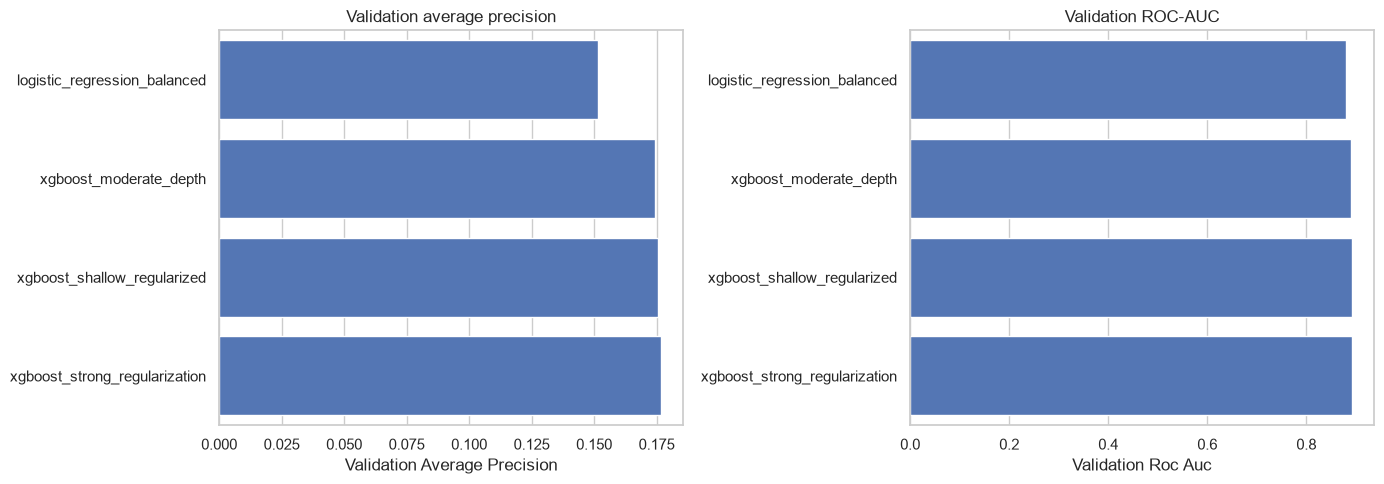

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

for axis, metric, title in [
    (axes[0], "validation_average_precision", "Validation average precision"),
    (axes[1], "validation_roc_auc", "Validation ROC-AUC"),
]:
    plot_frame = result.comparison.sort_values(metric, ascending=True)
    sns.barplot(data=plot_frame, x=metric, y="model", ax=axis, color="#4472C4")
    axis.set_title(title)
    axis.set_xlabel(metric.replace("_", " ").title())
    axis.set_ylabel("")

figure.tight_layout()
plt.show()

## 5. Review-capacity performance

These metrics rank applications at hypothetical manual-review capacities. They are not classification thresholds. The locked promotion guardrail uses recall at 5% capacity.

In [6]:
review_records = []

for model_name, split_metrics in result.metrics.items():
    for review_key, metrics in split_metrics["validation"]["review_rate_metrics"].items():
        review_records.append(
            {
                "model": model_name,
                "requested_review_rate": float(review_key),
                "actual_review_rate": metrics["actual_review_rate"],
                "review_count": metrics["review_count"],
                "expected_captured_fraud": metrics["captured_fraud_count"],
                "precision_at_capacity": metrics["precision_at_capacity"],
                "recall_at_capacity": metrics["recall_at_capacity"],
                "score_cutoff": metrics["score_cutoff"],
            }
        )

review_metrics = pd.DataFrame(review_records).sort_values(
    ["requested_review_rate", "model"]
)
display(review_metrics.style.format(precision=6))

,model,requested_review_rate,actual_review_rate,review_count,expected_captured_fraud,precision_at_capacity,recall_at_capacity,score_cutoff
0,logistic_regression_balanced,0.010000,0.010003,1082,264.000000,0.243993,0.182069,0.918104
8,xgboost_moderate_depth,0.010000,0.010003,1082,295.000000,0.272643,0.203448,0.933131
4,xgboost_shallow_regularized,0.010000,0.010003,1082,294.000000,0.271719,0.202759,0.935144
12,xgboost_strong_regularization,0.010000,0.010003,1082,289.000000,0.267098,0.199310,0.936265
1,logistic_regression_balanced,0.030000,0.030009,3246,514.000000,0.158349,0.354483,0.840701
9,xgboost_moderate_depth,0.030000,0.030009,3246,559.000000,0.172212,0.385517,0.859689
5,xgboost_shallow_regularized,0.030000,0.030009,3246,564.000000,0.173752,0.388966,0.863233
13,xgboost_strong_regularization,0.030000,0.030009,3246,562.000000,0.173136,0.387586,0.863643
2,logistic_regression_balanced,0.050000,0.050006,5409,686.000000,0.126826,0.473103,0.771853
10,xgboost_moderate_depth,0.050000,0.050006,5409,717.000000,0.132557,0.494483,0.796547


## 6. Temporal stability context

The calibration-to-validation movement is diagnostic. It can reveal instability, but only validation values enter the locked candidate rule.

,model,split,average_precision,roc_auc,brier_score,expected_calibration_error
0,logistic_regression_balanced,calibration,0.152822,0.882157,0.105151,0.224318
1,logistic_regression_balanced,validation,0.151703,0.880599,0.112137,0.231547
2,xgboost_shallow_regularized,calibration,0.190568,0.896121,0.106238,0.225608
3,xgboost_shallow_regularized,validation,0.175663,0.891420,0.120700,0.241737
4,xgboost_moderate_depth,calibration,0.190367,0.895161,0.099658,0.210868
5,xgboost_moderate_depth,validation,0.174475,0.891109,0.113263,0.226414
6,xgboost_strong_regularization,calibration,0.189026,0.895528,0.104347,0.221494
7,xgboost_strong_regularization,validation,0.176706,0.891986,0.119610,0.239085


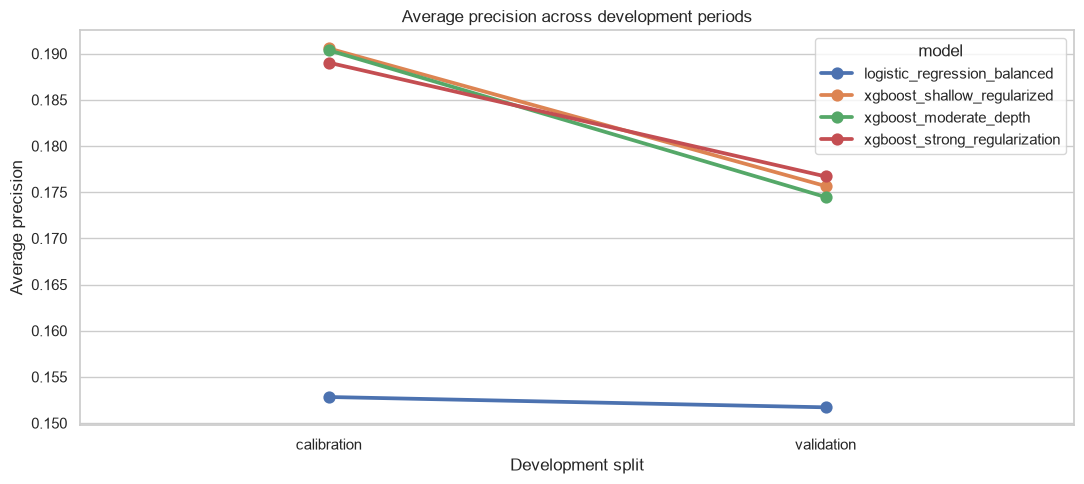

In [7]:
stability_records = []

for model_name, split_metrics in result.metrics.items():
    for split_name in ["calibration", "validation"]:
        metrics = split_metrics[split_name]
        stability_records.append(
            {
                "model": model_name,
                "split": split_name,
                "average_precision": metrics["pr_auc_average_precision"],
                "roc_auc": metrics["roc_auc"],
                "brier_score": metrics["brier_score"],
                "expected_calibration_error": metrics["expected_calibration_error"],
            }
        )

stability_metrics = pd.DataFrame(stability_records)
display(stability_metrics.style.format(precision=6))

plt.figure(figsize=(11, 5))
sns.pointplot(
    data=stability_metrics,
    x="split",
    y="average_precision",
    hue="model",
    markers="o",
)
plt.title("Average precision across development periods")
plt.xlabel("Development split")
plt.ylabel("Average precision")
plt.tight_layout()
plt.show()

## 7. XGBoost gain-importance audit

Built-in gain importance is used only as an inspection aid. It is not causal, can distribute importance across correlated inputs, and does not replace the later SHAP analysis.

,feature,gain_importance
0,housing_status_BA,0.343113
1,device_os_windows,0.130210
2,keep_alive_session,0.045555
3,prev_address_months_count__missing,0.042852
4,device_distinct_emails_8w,0.033215
5,has_other_cards,0.032844
6,phone_home_valid,0.028379
7,customer_age,0.022228
8,housing_status_BE,0.021437
9,email_is_free,0.021224


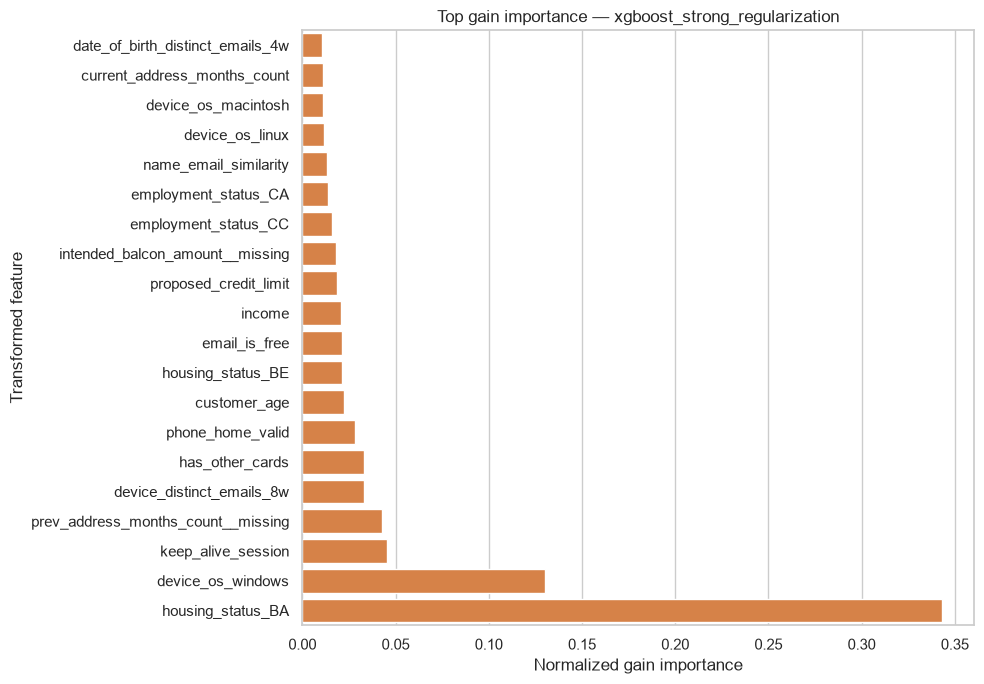

In [8]:
best_xgboost_name = result.decision.best_xgboost_model_name
best_xgboost_model = result.models[best_xgboost_name]
gain_importance = xgboost_importance_frame(best_xgboost_model)
display(gain_importance.head(25).style.format({"gain_importance": "{:.6f}"}))

top_gain = gain_importance.head(20).sort_values("gain_importance")
plt.figure(figsize=(10, 7))
sns.barplot(data=top_gain, x="gain_importance", y="feature", color="#ED7D31")
plt.title(f"Top gain importance — {best_xgboost_name}")
plt.xlabel("Normalized gain importance")
plt.ylabel("Transformed feature")
plt.tight_layout()
plt.show()

## 8. Selected-model diagnostic errors

The configured `0.50` cutoff is used only to inspect error modes. It does not alter model selection and must not be interpreted as the final operating threshold.

In [9]:
selected_name = result.decision.selected_model_name
selected_model = result.selected_model
selected_validation_metrics = result.metrics[selected_name]["validation"]
selected_probabilities = positive_class_probability(
    selected_model,
    development_data.validation_features,
)
selected_errors = build_error_analysis_frame(
    development_data.validation_features,
    development_data.validation_target,
    selected_probabilities,
    diagnostic_threshold=config["evaluation"]["diagnostic_threshold"],
    examples_per_error_type=20,
)

display(pd.Series(selected_validation_metrics["diagnostic_confusion_matrix"], name="rows").to_frame())
display(
    selected_errors.loc[
        :,
        [
            "source_index",
            "target",
            "fraud_probability",
            "diagnostic_prediction",
            "error_type",
            "income",
            "customer_age",
            "payment_type",
            "employment_status",
            "housing_status",
            "source",
        ],
    ]
)

,rows
true_negative,88943
false_positive,17775
false_negative,294
true_positive,1156


,source_index,target,fraud_probability,diagnostic_prediction,error_type,income,customer_age,payment_type,employment_status,housing_status,source
0,553567,0,0.996132,1,false_positive,0.9,60,AC,CC,BA,INTERNET
1,586799,0,0.995756,1,false_positive,0.9,60,AB,CC,BA,INTERNET
2,575064,0,0.995180,1,false_positive,0.9,60,AC,CC,BA,INTERNET
3,532622,0,0.995093,1,false_positive,0.9,50,AB,CA,BA,INTERNET
4,549102,0,0.994267,1,false_positive,0.9,50,AC,CB,BA,TELEAPP
5,528889,0,0.994010,1,false_positive,0.9,50,AC,CA,BA,INTERNET
6,560332,0,0.992443,1,false_positive,0.9,50,AD,CA,BA,INTERNET
7,573721,0,0.991799,1,false_positive,0.9,50,AB,CA,BA,INTERNET
8,570345,0,0.991768,1,false_positive,0.9,50,AC,CA,BA,INTERNET
9,570807,0,0.991459,1,false_positive,0.9,40,AC,CA,BA,INTERNET


## 9. Locked model-selection decision

The best XGBoost candidate is first ranked by validation evidence. It replaces the logistic baseline only if it clears both the minimum average-precision improvement and the maximum review-capacity recall-drop guardrails.

In [10]:
decision_record = pd.Series(asdict(result.decision), name="value")
display(decision_record.to_frame())

decision_word = "promoted" if result.decision.xgboost_promoted else "retained"
display(
    Markdown(
        f"**Development decision:** `{result.decision.selected_model_name}` was "
        f"**{decision_word}**.  \n{result.decision.reason}"
    )
)

,value
baseline_model_name,logistic_regression_balanced
best_xgboost_model_name,xgboost_strong_regularization
selected_model_name,xgboost_strong_regularization
xgboost_promoted,True
validation_average_precision_baseline,0.151703
validation_average_precision_challenger,0.176706
absolute_average_precision_improvement,0.025002
minimum_absolute_average_precision_improvement,0.002
operational_review_rate,0.05
validation_recall_at_capacity_baseline,0.473103


**Development decision:** `xgboost_strong_regularization` was **promoted**.  
The best XGBoost candidate cleared both the locked average-precision improvement and review-capacity recall guardrails.

## 10. Artifact and leakage audit

Artifacts are local and ignored by Git. The assertions below fail closed if the experiment ever reports test access, probability calibration, or business-threshold selection during Phase 4.

In [11]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in result.artifact_paths.items()
    ]
)
metadata_path = result.artifact_paths["metadata"]
phase4_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
guardrails = {
    "test_evaluated": phase4_metadata["test_evaluated"],
    "test_features_exposed": phase4_metadata["test_features_exposed"],
    "preprocessing_fitted_inside_model_pipeline": phase4_metadata["preprocessing_fitted_inside_model_pipeline"],
    "scale_pos_weight_source": phase4_metadata["scale_pos_weight_source"],
    "model_selected_on": phase4_metadata["model_selected_on"],
    "probability_calibrated": phase4_metadata["probability_calibrated"],
    "business_threshold_selected": phase4_metadata["business_threshold_selected"],
}

assert guardrails["test_evaluated"] is False
assert guardrails["test_features_exposed"] is False
assert guardrails["preprocessing_fitted_inside_model_pipeline"] is True
assert guardrails["scale_pos_weight_source"] == "training_target_only"
assert guardrails["model_selected_on"] == "validation_periods_only"
assert guardrails["probability_calibrated"] is False
assert guardrails["business_threshold_selected"] is False
display(artifact_table)
display(pd.Series(guardrails, name="value").to_frame())

,artifact,path
0,model:logistic_regression_balanced,D:\latihan\fraudshield\artifacts\phase4\logist...
1,model:xgboost_shallow_regularized,D:\latihan\fraudshield\artifacts\phase4\xgboos...
2,model:xgboost_moderate_depth,D:\latihan\fraudshield\artifacts\phase4\xgboos...
3,model:xgboost_strong_regularization,D:\latihan\fraudshield\artifacts\phase4\xgboos...
4,selected_model,D:\latihan\fraudshield\artifacts\phase4\xgboos...
5,metrics,D:\latihan\fraudshield\artifacts\phase4\develo...
6,comparison,D:\latihan\fraudshield\artifacts\phase4\model_...
7,decision,D:\latihan\fraudshield\artifacts\phase4\select...
8,importance:xgboost_shallow_regularized,D:\latihan\fraudshield\artifacts\phase4\xgboos...
9,importance:xgboost_moderate_depth,D:\latihan\fraudshield\artifacts\phase4\xgboos...


,value
test_evaluated,False
test_features_exposed,False
preprocessing_fitted_inside_model_pipeline,True
scale_pos_weight_source,training_target_only
model_selected_on,validation_periods_only
probability_calibrated,False
business_threshold_selected,False


## Kesimpulan Fase 4

Berdasarkan kebijakan seleksi model yang telah ditetapkan sebelum training,
`xgboost_strong_regularization` dipilih sebagai kandidat model pengembangan.

Pada validation month 6, average precision meningkat dari `0.151703` pada
class-weighted logistic regression menjadi `0.176706` pada model terpilih.
Peningkatan tersebut sebesar `0.025002` secara absolut atau sekitar `16.48%`
secara relatif. ROC-AUC juga meningkat dari `0.880599` menjadi `0.891986`.

Pada kapasitas review 5%, recall meningkat dari `0.473103` menjadi `0.491724`.
Dengan jumlah review yang sama, yaitu 5.409 aplikasi, model XGBoost menangkap
713 aplikasi fraud, sedangkan logistic baseline menangkap 686 aplikasi fraud.
Artinya, terdapat tambahan 27 aplikasi fraud yang berhasil teridentifikasi.

Kedua guardrail promosi model berhasil dipenuhi:

- Peningkatan average precision melampaui batas minimum `0.002`.
- Recall pada kapasitas review 5% meningkat sebesar `0.018621` dan tidak
  mengalami penurunan.

Performa ketiga kandidat XGBoost relatif berdekatan. Kandidat shallow memiliki
recall yang sedikit lebih tinggi pada kapasitas review 5%, tetapi
`xgboost_strong_regularization` memperoleh validation average precision
tertinggi. Karena average precision telah ditetapkan sebagai metrik utama
sebelum training, pemilihan model tetap mengikuti hasil tersebut.

Validation Brier score model terpilih (`0.119610`) lebih buruk dibandingkan
logistic baseline (`0.112137`). Oleh karena itu, keputusan Fase 4 hanya
menetapkan model dengan kemampuan ranking terbaik. Probabilitas model belum
dapat dianggap terkalibrasi dan masih harus diproses pada Fase 5.

Month 7 tetap untouched. Fitur dan label test tidak digunakan untuk training,
perbandingan kandidat, model selection, maupun pelaporan Fase 4.